#**Tecnicas de Optimización en Deeplearning**

Demostraciones que se deben hacer
1. ¿Cómo cambia el aprendizaje?
2. ¿Cómo influyen los hiperparametros?
3. ¿Cómo infloyen los optimizadores?
4. Evidencias

#**Importación de Librerías**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

#**Carga de Datos**

In [7]:
data=load_digits()
X=data.data
y=data.target
iteraciones=2000

#**Split**
Entrenamiento con una asignación para test de 20%

In [8]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=7)

#**Escalado**

In [9]:
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)


#**Primer Experimento**
#Tazas de Aprendizaje

LR= 0.0001 Accurancy:  0.9666666666666667
LR= 0.001 Accurancy:  0.9694444444444444
LR= 0.01 Accurancy:  0.9722222222222222


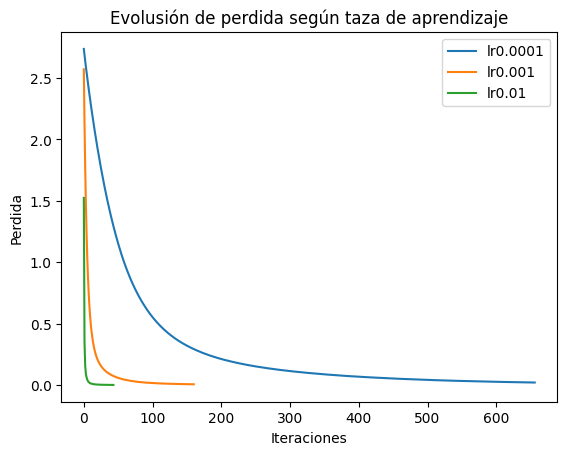

In [10]:
#Tazas de Aprendizaje
tazas_aprendizaje=[0.0001, 0.001, 0.01]

for lr in tazas_aprendizaje:
    mlp=MLPClassifier(
        hidden_layer_sizes=(64,),
        learning_rate_init=lr,
        max_iter=iteraciones,
        random_state=7
    )

    mlp.fit(X_train_s, y_train)
    pred=mlp.predict(X_test_s)

    print(f"LR= {lr} Accurancy: ", accuracy_score(y_test, pred))
    plt.plot(mlp.loss_curve_, label=f"lr{lr}")
#Graficación del Experimento

plt.title("Evolusión de perdida según taza de aprendizaje")
plt.xlabel("Iteraciones")
plt.ylabel("Perdida")
plt.legend()
plt.show()


#**Segundo Experimento**
#Optimizadores

Optimizador=SGD Accurancy:  0.9583333333333334
Optimizador=ADAM Accurancy:  0.9694444444444444
Optimizador=LBFGS Accurancy:  0.9583333333333334


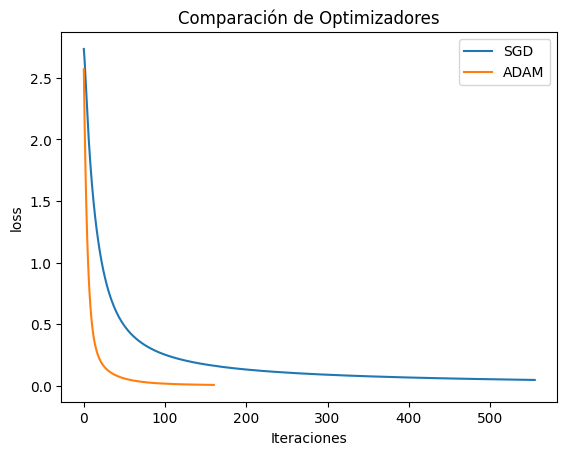

In [11]:
optimizadores=["sgd", "adam", "lbfgs"]

for optimizador in optimizadores:
    mlp=MLPClassifier(
        hidden_layer_sizes=(64,),
        solver=optimizador,
        max_iter=iteraciones,
        random_state=7
    )
    mlp.fit(X_train_s, y_train)
    pred=mlp.predict(X_test_s)

    print(f"Optimizador={optimizador.upper()} Accurancy: ",accuracy_score(y_test, pred))

    if hasattr(mlp, "loss_curve_"):
        plt.plot(mlp.loss_curve_, label=optimizador.upper())

plt.title("Comparación de Optimizadores")
plt.xlabel("Iteraciones")
plt.ylabel("loss")
plt.legend()
plt.show()